# Tutorial 23: Multi-Objective Optimization

This tutorial covers gradient-based multi-objective optimization (MOO) for chemical engineering applications. We'll explore:

1. Scalarization methods (weighted sum, Chebyshev)
2. Gradient-based Pareto optimization
3. Multi-gradient descent algorithm (MGDA)
4. Hypervolume maximization
5. Constraint handling in MOO
6. Chemical engineering example: Process optimization (cost, efficiency, environmental impact)

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jacobian, vmap, jit
import optax
import matplotlib.pyplot as plt
from functools import partial

jax.config.update('jax_enable_x64', True)

## 1. Scalarization Methods

The simplest approach to MOO is scalarization: combining multiple objectives into a single scalar.

### Weighted Sum Method

$$\min_x \sum_{i=1}^{m} w_i f_i(x)$$

where $w_i \geq 0$ and $\sum w_i = 1$.

In [2]:
# Example: Two conflicting objectives
def objective_1(x):
    """Minimize squared distance from origin."""
    return jnp.sum(x ** 2)

def objective_2(x):
    """Minimize squared distance from (2, 2)."""
    return jnp.sum((x - 2) ** 2)

def weighted_sum(x, weights):
    """Weighted sum scalarization."""
    f1 = objective_1(x)
    f2 = objective_2(x)
    return weights[0] * f1 + weights[1] * f2

# Optimize for different weight combinations
def optimize_weighted(weights, n_steps=100):
    x = jnp.array([1.0, 1.0])
    learning_rate = 0.1
    
    for _ in range(n_steps):
        g = grad(weighted_sum)(x, weights)
        x = x - learning_rate * g
    
    return x, objective_1(x), objective_2(x)

# Trace Pareto front by varying weights
n_points = 20
weight_range = jnp.linspace(0.01, 0.99, n_points)
pareto_points = []

for w1 in weight_range:
    weights = jnp.array([w1, 1 - w1])
    x_opt, f1, f2 = optimize_weighted(weights)
    pareto_points.append((f1, f2, x_opt))

f1_values = jnp.array([p[0] for p in pareto_points])
f2_values = jnp.array([p[1] for p in pareto_points])

print("Weighted Sum Pareto Front:")
print(f"f1 range: [{f1_values.min():.3f}, {f1_values.max():.3f}]")
print(f"f2 range: [{f2_values.min():.3f}, {f2_values.max():.3f}]")

W0000 00:00:1767135067.806361 4132947 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767135067.814605 4132947 service.cc:145] XLA service 0x600000e54200 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767135067.814615 4132947 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767135067.815577 4132947 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767135067.815584 4132947 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


Weighted Sum Pareto Front:
f1 range: [0.001, 7.841]
f2 range: [0.001, 7.841]


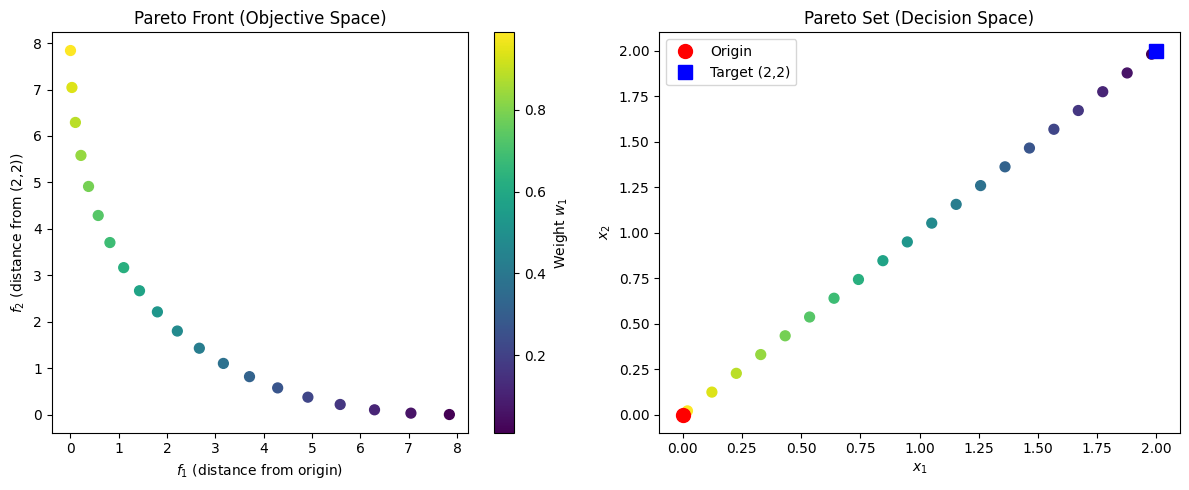

In [3]:
# Visualize Pareto front
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Objective space
ax1.scatter(f1_values, f2_values, c=weight_range, cmap='viridis', s=50)
ax1.set_xlabel('$f_1$ (distance from origin)')
ax1.set_ylabel('$f_2$ (distance from (2,2))')
ax1.set_title('Pareto Front (Objective Space)')
cbar = plt.colorbar(ax1.collections[0], ax=ax1)
cbar.set_label('Weight $w_1$')

# Decision space
x_opts = jnp.array([p[2] for p in pareto_points])
ax2.scatter(x_opts[:, 0], x_opts[:, 1], c=weight_range, cmap='viridis', s=50)
ax2.plot([0], [0], 'ro', markersize=10, label='Origin')
ax2.plot([2], [2], 'bs', markersize=10, label='Target (2,2)')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_title('Pareto Set (Decision Space)')
ax2.legend()

plt.tight_layout()
plt.show()

### Chebyshev Scalarization

Overcomes the limitation of weighted sum (can find non-convex Pareto fronts):

$$\min_x \max_{i=1}^{m} w_i |f_i(x) - z_i^*|$$

where $z^*$ is the ideal point (best achievable for each objective).

In [4]:
def chebyshev_scalarization(x, weights, ideal_point):
    """
    Chebyshev scalarization with smooth max.
    
    Uses softmax approximation for differentiability.
    """
    f1 = objective_1(x)
    f2 = objective_2(x)
    objectives = jnp.array([f1, f2])
    
    # Weighted deviations from ideal
    deviations = weights * jnp.abs(objectives - ideal_point)
    
    # Smooth max (differentiable)
    temperature = 10.0
    smooth_max = jnp.log(jnp.sum(jnp.exp(temperature * deviations))) / temperature
    
    return smooth_max

# Find ideal point (optimize each objective separately)
def find_ideal_point():
    # Optimize f1
    x1 = jnp.array([0.5, 0.5])
    for _ in range(100):
        x1 = x1 - 0.1 * grad(objective_1)(x1)
    
    # Optimize f2
    x2 = jnp.array([0.5, 0.5])
    for _ in range(100):
        x2 = x2 - 0.1 * grad(objective_2)(x2)
    
    return jnp.array([objective_1(x1), objective_2(x2)])

ideal = find_ideal_point()
print(f"Ideal point: ({ideal[0]:.4f}, {ideal[1]:.4f})")

# Optimize with Chebyshev
def optimize_chebyshev(weights, ideal, n_steps=200):
    x = jnp.array([1.0, 1.0])
    learning_rate = 0.05
    
    for _ in range(n_steps):
        g = grad(chebyshev_scalarization)(x, weights, ideal)
        x = x - learning_rate * g
    
    return x, objective_1(x), objective_2(x)

# Trace Pareto front
chebyshev_points = []
for w1 in weight_range:
    weights = jnp.array([w1, 1 - w1])
    x_opt, f1, f2 = optimize_chebyshev(weights, ideal)
    chebyshev_points.append((f1, f2))

f1_cheb = jnp.array([p[0] for p in chebyshev_points])
f2_cheb = jnp.array([p[1] for p in chebyshev_points])

print(f"\nChebyshev Pareto Front:")
print(f"f1 range: [{f1_cheb.min():.3f}, {f1_cheb.max():.3f}]")
print(f"f2 range: [{f2_cheb.min():.3f}, {f2_cheb.max():.3f}]")

Ideal point: (0.0000, 0.0000)



Chebyshev Pareto Front:
f1 range: [0.003, 7.673]
f2 range: [0.003, 7.673]


## 2. Gradient-Based Pareto Optimization

Instead of scalarization, we can directly find Pareto-optimal solutions by analyzing the gradients of all objectives.

In [5]:
def compute_all_gradients(x, objectives):
    """Compute gradients of all objectives."""
    return jnp.array([grad(obj)(x) for obj in objectives])

def is_pareto_stationary(gradients, tol=1e-6):
    """
    Check if point is Pareto stationary.
    
    A point is Pareto stationary if there exists weights w >= 0
    such that sum(w_i * grad_i) = 0.
    """
    # For 2 objectives, check if gradients point in opposite directions
    g1, g2 = gradients[0], gradients[1]
    
    # Normalize gradients
    g1_norm = g1 / (jnp.linalg.norm(g1) + 1e-10)
    g2_norm = g2 / (jnp.linalg.norm(g2) + 1e-10)
    
    # Check if they're (approximately) opposite
    dot_product = jnp.dot(g1_norm, g2_norm)
    
    return dot_product < -0.99  # Approximately opposite

# Demonstrate on our example
objectives = [objective_1, objective_2]

# Check various points
test_points = [
    jnp.array([0.0, 0.0]),
    jnp.array([1.0, 1.0]),
    jnp.array([2.0, 2.0]),
    jnp.array([0.5, 0.5]),
]

print("Pareto Stationarity Check:")
print("=" * 50)
for x in test_points:
    grads = compute_all_gradients(x, objectives)
    is_ps = is_pareto_stationary(grads)
    g1_norm = jnp.linalg.norm(grads[0])
    g2_norm = jnp.linalg.norm(grads[1])
    print(f"x={x}: |grad1|={g1_norm:.3f}, |grad2|={g2_norm:.3f}, Pareto stationary: {is_ps}")

Pareto Stationarity Check:
x=[0. 0.]: |grad1|=0.000, |grad2|=5.657, Pareto stationary: False
x=[1. 1.]: |grad1|=2.828, |grad2|=2.828, Pareto stationary: True
x=[2. 2.]: |grad1|=5.657, |grad2|=0.000, Pareto stationary: False
x=[0.5 0.5]: |grad1|=1.414, |grad2|=4.243, Pareto stationary: True


## 3. Multi-Gradient Descent Algorithm (MGDA)

MGDA finds a common descent direction for all objectives by solving:

$$\min_{d} \|d\|^2 \quad \text{s.t.} \quad d \in \text{conv}\{\nabla f_1, \ldots, \nabla f_m\}$$

This finds the minimum-norm element in the convex hull of gradients.

In [6]:
def mgda_direction(gradients):
    """
    Find MGDA common descent direction.
    
    For 2 objectives, this has a closed-form solution.
    """
    g1, g2 = gradients[0], gradients[1]
    
    # Solve: min ||alpha * g1 + (1-alpha) * g2||^2
    # d/dalpha = 2 * (g1 - g2) @ (alpha * g1 + (1-alpha) * g2) = 0
    # alpha * ||g1||^2 - alpha * g1@g2 + (1-alpha) * g1@g2 - (1-alpha) * ||g2||^2 = 0
    # alpha * (||g1||^2 - 2*g1@g2 + ||g2||^2) = ||g2||^2 - g1@g2
    
    g1_g1 = jnp.dot(g1, g1)
    g2_g2 = jnp.dot(g2, g2)
    g1_g2 = jnp.dot(g1, g2)
    
    denom = g1_g1 - 2 * g1_g2 + g2_g2
    
    # Handle edge cases
    alpha = jnp.where(
        jnp.abs(denom) < 1e-10,
        0.5,  # Gradients are parallel
        jnp.clip((g2_g2 - g1_g2) / denom, 0.0, 1.0)
    )
    
    # Common descent direction
    direction = alpha * g1 + (1 - alpha) * g2
    
    return direction, alpha

def mgda_update(x, objectives, learning_rate=0.1):
    """Perform one MGDA update step."""
    gradients = compute_all_gradients(x, objectives)
    direction, alpha = mgda_direction(gradients)
    
    # Check if we're at Pareto stationary point
    if jnp.linalg.norm(direction) < 1e-6:
        return x, True, alpha
    
    x_new = x - learning_rate * direction
    return x_new, False, alpha

# Run MGDA optimization
x = jnp.array([0.3, 0.7])
trajectory = [(x, objective_1(x), objective_2(x))]

for i in range(100):
    x, converged, alpha = mgda_update(x, objectives)
    trajectory.append((x, objective_1(x), objective_2(x)))
    if converged:
        print(f"Converged at iteration {i}")
        break

print(f"\nMGDA Result:")
print(f"Final x: {x}")
print(f"f1: {objective_1(x):.4f}")
print(f"f2: {objective_2(x):.4f}")

Converged at iteration 60

MGDA Result:
Final x: [0.49999969 0.50000031]
f1: 0.5000
f2: 4.5000


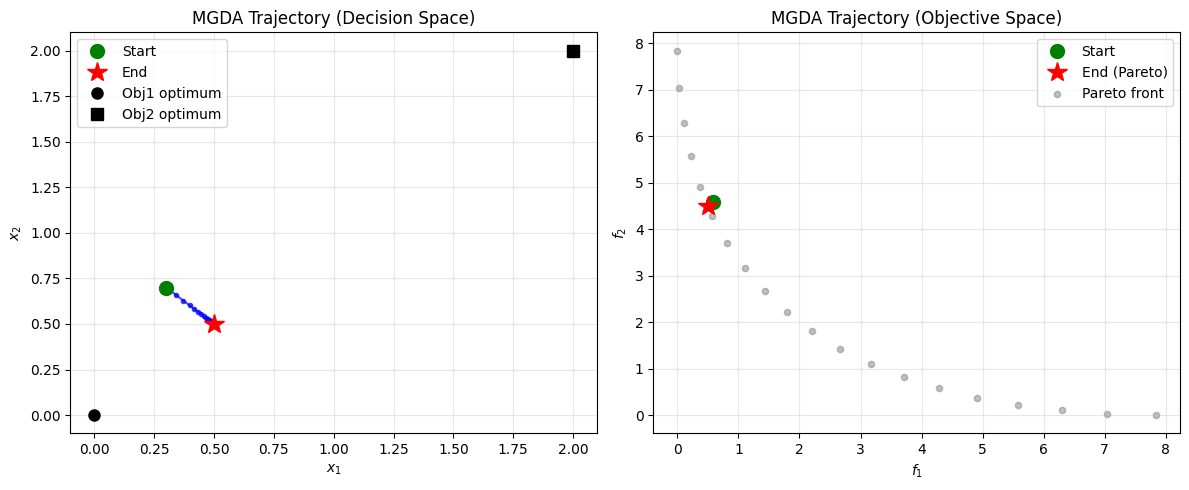

In [7]:
# Visualize MGDA trajectory
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Decision space trajectory
x_traj = jnp.array([t[0] for t in trajectory])
ax1.plot(x_traj[:, 0], x_traj[:, 1], 'b-o', markersize=3, alpha=0.7)
ax1.plot(x_traj[0, 0], x_traj[0, 1], 'go', markersize=10, label='Start')
ax1.plot(x_traj[-1, 0], x_traj[-1, 1], 'r*', markersize=15, label='End')
ax1.plot([0], [0], 'ko', markersize=8, label='Obj1 optimum')
ax1.plot([2], [2], 'ks', markersize=8, label='Obj2 optimum')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_title('MGDA Trajectory (Decision Space)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Objective space trajectory
f1_traj = jnp.array([t[1] for t in trajectory])
f2_traj = jnp.array([t[2] for t in trajectory])
ax2.plot(f1_traj, f2_traj, 'b-o', markersize=3, alpha=0.7)
ax2.plot(f1_traj[0], f2_traj[0], 'go', markersize=10, label='Start')
ax2.plot(f1_traj[-1], f2_traj[-1], 'r*', markersize=15, label='End (Pareto)')
ax2.scatter(f1_values, f2_values, c='gray', s=20, alpha=0.5, label='Pareto front')
ax2.set_xlabel('$f_1$')
ax2.set_ylabel('$f_2$')
ax2.set_title('MGDA Trajectory (Objective Space)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# MGDA for more than 2 objectives (general case)

def mgda_direction_general(gradients):
    """
    MGDA for m objectives using Frank-Wolfe algorithm.
    
    Solves: min ||sum(alpha_i * g_i)||^2 s.t. alpha >= 0, sum(alpha) = 1
    """
    m, n = gradients.shape  # m objectives, n variables
    
    # Initialize with uniform weights
    alpha = jnp.ones(m) / m
    
    # Frank-Wolfe iterations
    for _ in range(50):
        # Current direction
        d = alpha @ gradients  # shape (n,)
        
        # Find gradient wrt alpha
        grad_alpha = gradients @ d  # shape (m,)
        
        # Find the corner of simplex that minimizes linear approximation
        s = jnp.zeros(m)
        s = s.at[jnp.argmin(grad_alpha)].set(1.0)
        
        # Line search (simple step size)
        step_size = 2.0 / (_ + 2)  # Decaying step size
        alpha = (1 - step_size) * alpha + step_size * s
    
    direction = alpha @ gradients
    return direction, alpha

# Test with 3 objectives
def objective_3(x):
    """Minimize squared distance from (-1, 1)."""
    return jnp.sum((x - jnp.array([-1, 1])) ** 2)

objectives_3 = [objective_1, objective_2, objective_3]

x = jnp.array([0.3, 0.7])
gradients = jnp.array([grad(obj)(x) for obj in objectives_3])
direction, alpha = mgda_direction_general(gradients)

print("MGDA with 3 objectives:")
print(f"Weights: {alpha}")
print(f"Common descent direction: {direction}")
print(f"Direction norm: {jnp.linalg.norm(direction):.4f}")

MGDA with 3 objectives:
Weights: [0.53568627 0.24156863 0.2227451 ]
Common descent direction: [ 0.07921569 -0.01176471]
Direction norm: 0.0801


## 4. Hypervolume Maximization

Hypervolume indicator measures the quality of a Pareto front approximation. We can optimize it directly using gradients.

In [9]:
def hypervolume_2d(points, reference):
    """
    Compute 2D hypervolume indicator.
    
    points: (n_points, 2) array of objective values
    reference: (2,) reference point (should dominate all points)
    """
    n_points = points.shape[0]
    
    # Sort by first objective
    sorted_indices = jnp.argsort(points[:, 0])
    sorted_points = points[sorted_indices]
    
    # Compute hypervolume contribution of each point
    hv = 0.0
    prev_x = reference[0]  # Start from reference
    
    for i in range(n_points - 1, -1, -1):
        x_i, y_i = sorted_points[i]
        # Height is from point to reference
        height = reference[1] - y_i
        # Width is from previous x to current x
        width = prev_x - x_i
        hv += height * width
        prev_x = x_i
    
    return hv

# Smooth hypervolume for gradient computation
def smooth_hypervolume_2d(x_set, objectives, reference, temperature=0.1):
    """
    Differentiable hypervolume approximation using soft sorting.
    
    x_set: (n_points, n_vars) decision variables
    """
    # Evaluate objectives for all points
    f_values = vmap(lambda x: jnp.array([obj(x) for obj in objectives]))(x_set)
    
    # Simple approximation: use weighted contribution
    contributions = (reference[0] - f_values[:, 0]) * (reference[1] - f_values[:, 1])
    
    # Use softmax weighting to handle dominance
    # This is a simplification; true differentiable HV is more complex
    return jnp.mean(jnp.maximum(contributions, 0))

# Demonstrate hypervolume computation
reference = jnp.array([10.0, 10.0])

# Some Pareto front points
pareto_sample = jnp.array([
    [0.0, 8.0],
    [2.0, 2.0],
    [8.0, 0.0]
])

hv = hypervolume_2d(pareto_sample, reference)
print(f"Hypervolume of sample front: {hv:.2f}")

# Theoretical maximum (if we could achieve ideal point everywhere)
max_hv = reference[0] * reference[1]
print(f"Reference hypervolume: {max_hv:.2f}")
print(f"Ratio: {hv/max_hv:.2%}")

Hypervolume of sample front: 72.00
Reference hypervolume: 100.00
Ratio: 72.00%


## 5. Constraint Handling in MOO

Real engineering problems have constraints. We can handle them with penalty methods or Lagrangian approaches.

In [10]:
def constraint_1(x):
    """Constraint: x1 + x2 <= 3."""
    return x[0] + x[1] - 3  # <= 0

def constraint_2(x):
    """Constraint: x1 >= 0.2."""
    return 0.2 - x[0]  # <= 0

def penalty_scalarization(x, weights, penalty_coeff=100.0):
    """
    Weighted sum with constraint penalties.
    """
    f1 = objective_1(x)
    f2 = objective_2(x)
    
    # Constraint violations (max(g, 0)^2)
    c1_violation = jnp.maximum(constraint_1(x), 0) ** 2
    c2_violation = jnp.maximum(constraint_2(x), 0) ** 2
    penalty = penalty_coeff * (c1_violation + c2_violation)
    
    return weights[0] * f1 + weights[1] * f2 + penalty

# Optimize with constraints
def optimize_constrained(weights, n_steps=200):
    x = jnp.array([1.0, 1.0])
    learning_rate = 0.05
    
    for _ in range(n_steps):
        g = grad(penalty_scalarization)(x, weights)
        x = x - learning_rate * g
    
    return x, objective_1(x), objective_2(x)

# Trace constrained Pareto front
constrained_points = []
for w1 in weight_range:
    weights = jnp.array([w1, 1 - w1])
    x_opt, f1, f2 = optimize_constrained(weights)
    is_feasible = (constraint_1(x_opt) <= 0.01) and (constraint_2(x_opt) <= 0.01)
    if is_feasible:
        constrained_points.append((f1, f2, x_opt))

if constrained_points:
    f1_const = jnp.array([p[0] for p in constrained_points])
    f2_const = jnp.array([p[1] for p in constrained_points])
    print(f"Constrained Pareto front: {len(constrained_points)} points")
else:
    print("No feasible points found")

Constrained Pareto front: 19 points


<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:8: SyntaxWarning: invalid escape sequence '\g'
/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_43019/3519282167.py:8: SyntaxWarning: invalid escape sequence '\g'
  ax1.axvline(0.2, color='blue', linestyle='--', label='$x_1 \geq 0.2$')


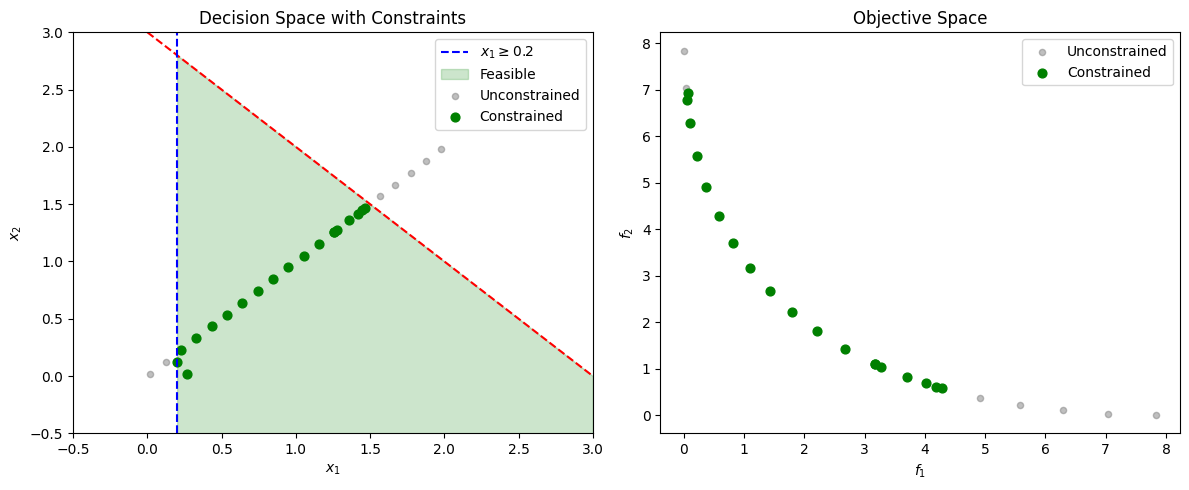

In [11]:
# Visualize constrained vs unconstrained
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Decision space with constraints
xx, yy = jnp.meshgrid(jnp.linspace(-0.5, 3, 100), jnp.linspace(-0.5, 3, 100))
c1_values = xx + yy - 3
ax1.contour(xx, yy, c1_values, levels=[0], colors='red', linestyles='--')
ax1.axvline(0.2, color='blue', linestyle='--', label='$x_1 \geq 0.2$')
ax1.fill_between([0.2, 3], [-0.5, -0.5], [3-0.2, 0], alpha=0.2, color='green', label='Feasible')

# Unconstrained Pareto set
x_unc = jnp.array([p[2] for p in pareto_points])
ax1.scatter(x_unc[:, 0], x_unc[:, 1], c='gray', s=20, alpha=0.5, label='Unconstrained')

# Constrained Pareto set
if constrained_points:
    x_const = jnp.array([p[2] for p in constrained_points])
    ax1.scatter(x_const[:, 0], x_const[:, 1], c='green', s=40, label='Constrained')

ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_title('Decision Space with Constraints')
ax1.legend()
ax1.set_xlim(-0.5, 3)
ax1.set_ylim(-0.5, 3)

# Objective space
ax2.scatter(f1_values, f2_values, c='gray', s=20, alpha=0.5, label='Unconstrained')
if constrained_points:
    ax2.scatter(f1_const, f2_const, c='green', s=40, label='Constrained')
ax2.set_xlabel('$f_1$')
ax2.set_ylabel('$f_2$')
ax2.set_title('Objective Space')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Chemical Engineering Example: Process Optimization

Optimize a CSTR with three objectives:
1. Maximize conversion (profit)
2. Minimize energy consumption (cost)
3. Minimize waste generation (environmental)

In [12]:
class MultiObjectiveCSTR:
    """
    CSTR with multiple optimization objectives.
    
    Decision variables: [T, tau, C_in] (temperature, residence time, inlet concentration)
    """
    
    # Kinetic parameters
    k0 = 1e6  # Pre-exponential factor
    E_over_R = 5000.0  # Activation energy / R
    delta_H = -50000.0  # Heat of reaction (J/mol)
    
    @staticmethod
    def conversion(x):
        """Calculate conversion (to maximize -> minimize negative)."""
        T, tau, C_in = x
        k = MultiObjectiveCSTR.k0 * jnp.exp(-MultiObjectiveCSTR.E_over_R / T)
        conv = k * tau / (1 + k * tau)
        return -conv  # Negative because we minimize
    
    @staticmethod
    def energy_consumption(x):
        """Calculate energy consumption (heating + mixing)."""
        T, tau, C_in = x
        
        # Heating cost (relative to ambient T=300K)
        heating = 0.1 * (T - 300) ** 2
        
        # Mixing/pumping cost (proportional to throughput)
        mixing = 10.0 / tau  # Shorter tau = higher throughput = more energy
        
        # Cooling to remove reaction heat
        k = MultiObjectiveCSTR.k0 * jnp.exp(-MultiObjectiveCSTR.E_over_R / T)
        conv = k * tau / (1 + k * tau)
        C_out = C_in * (1 - conv)
        rate = k * C_out
        cooling = 0.001 * jnp.abs(MultiObjectiveCSTR.delta_H) * rate * tau
        
        return heating + mixing + cooling
    
    @staticmethod
    def waste_generation(x):
        """Calculate waste/byproduct generation."""
        T, tau, C_in = x
        
        # Byproduct formation (increases with T and residence time)
        k_byproduct = 1e4 * jnp.exp(-4000.0 / T)  # Lower activation energy
        
        k = MultiObjectiveCSTR.k0 * jnp.exp(-MultiObjectiveCSTR.E_over_R / T)
        conv = k * tau / (1 + k * tau)
        C_out = C_in * (1 - conv)
        
        # Byproduct from side reactions
        byproduct = k_byproduct * C_out * tau
        
        # Unreacted feed as waste
        unreacted = C_out
        
        return byproduct + 0.5 * unreacted
    
    @staticmethod
    def constraints(x):
        """Physical constraints."""
        T, tau, C_in = x
        return jnp.array([
            300 - T,      # T >= 300 K
            T - 450,      # T <= 450 K
            1 - tau,      # tau >= 1 s
            tau - 100,    # tau <= 100 s
            0.1 - C_in,   # C_in >= 0.1 mol/L
            C_in - 5.0    # C_in <= 5.0 mol/L
        ])

# Test the objectives
x_test = jnp.array([350.0, 20.0, 1.0])  # T, tau, C_in

print("CSTR Multi-Objective Optimization")
print("=" * 50)
print(f"Test point: T={x_test[0]:.0f}K, tau={x_test[1]:.0f}s, C_in={x_test[2]:.1f} mol/L")
print(f"Conversion: {-MultiObjectiveCSTR.conversion(x_test):.3f}")
print(f"Energy: {MultiObjectiveCSTR.energy_consumption(x_test):.1f}")
print(f"Waste: {MultiObjectiveCSTR.waste_generation(x_test):.3f}")

CSTR Multi-Objective Optimization
Test point: T=350K, tau=20s, C_in=1.0 mol/L
Conversion: 0.926
Energy: 296.8
Waste: 0.198


In [13]:
# Multi-objective optimization using weighted sum

def cstr_scalarized(x, weights, penalty=1000.0):
    """Scalarized CSTR objective with constraints."""
    # Normalize objectives to similar scales
    f1 = MultiObjectiveCSTR.conversion(x)  # ~ [-1, 0]
    f2 = MultiObjectiveCSTR.energy_consumption(x) / 100  # Normalize
    f3 = MultiObjectiveCSTR.waste_generation(x)  # ~ [0, 1]
    
    # Weighted sum
    obj = weights[0] * f1 + weights[1] * f2 + weights[2] * f3
    
    # Constraint penalties
    violations = jnp.maximum(MultiObjectiveCSTR.constraints(x), 0)
    penalty_term = penalty * jnp.sum(violations ** 2)
    
    return obj + penalty_term

def optimize_cstr(weights, n_steps=500):
    """Optimize CSTR for given weight combination."""
    # Start from middle of feasible region
    x = jnp.array([375.0, 30.0, 1.5])
    
    optimizer = optax.adam(0.5)
    opt_state = optimizer.init(x)
    
    @jit
    def step(x, opt_state):
        g = grad(cstr_scalarized)(x, weights)
        updates, opt_state = optimizer.update(g, opt_state)
        x = optax.apply_updates(x, updates)
        return x, opt_state
    
    for _ in range(n_steps):
        x, opt_state = step(x, opt_state)
    
    # Check feasibility
    violations = jnp.max(MultiObjectiveCSTR.constraints(x))
    is_feasible = violations <= 0.1
    
    return x, is_feasible

# Generate Pareto front
from itertools import product

weight_values = [0.1, 0.3, 0.5, 0.7, 0.9]
pareto_cstr = []

print("Generating CSTR Pareto front...")
for w1 in weight_values:
    for w2 in weight_values:
        w3 = max(0.01, 1 - w1 - w2)
        if w3 > 0:
            weights = jnp.array([w1, w2, w3])
            weights = weights / weights.sum()  # Normalize
            
            x_opt, feasible = optimize_cstr(weights)
            
            if feasible:
                conv = -MultiObjectiveCSTR.conversion(x_opt)
                energy = MultiObjectiveCSTR.energy_consumption(x_opt)
                waste = MultiObjectiveCSTR.waste_generation(x_opt)
                pareto_cstr.append({
                    'x': x_opt,
                    'conversion': conv,
                    'energy': energy,
                    'waste': waste,
                    'weights': weights
                })

print(f"Found {len(pareto_cstr)} Pareto-optimal solutions")

Generating CSTR Pareto front...


Found 25 Pareto-optimal solutions


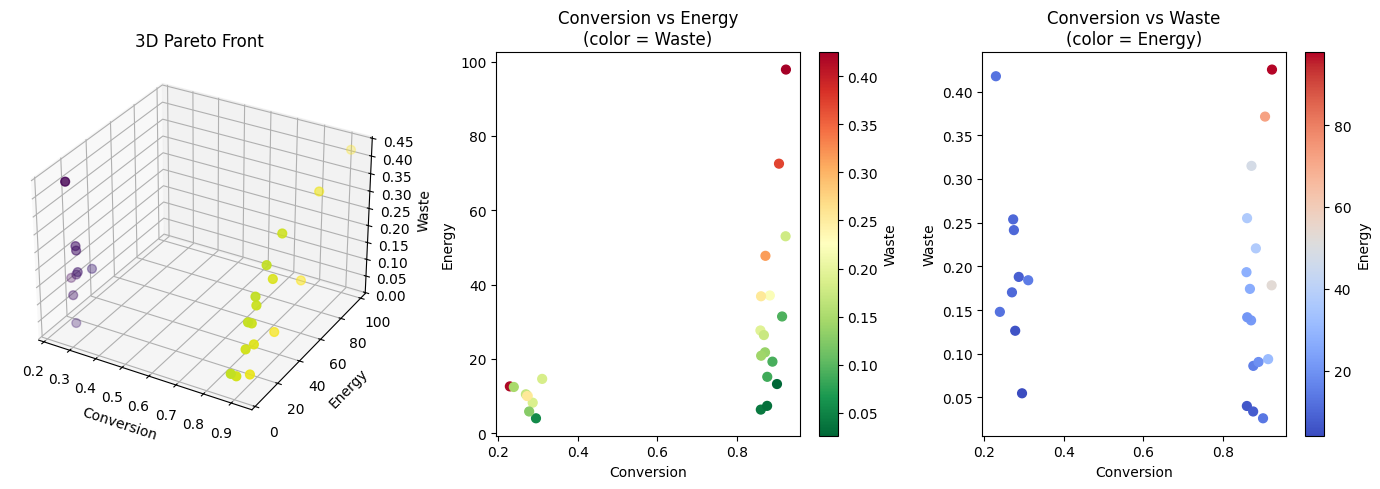

In [14]:
# Visualize 3D Pareto front
from mpl_toolkits.mplot3d import Axes3D

conversions = jnp.array([p['conversion'] for p in pareto_cstr])
energies = jnp.array([p['energy'] for p in pareto_cstr])
wastes = jnp.array([p['waste'] for p in pareto_cstr])

fig = plt.figure(figsize=(14, 5))

# 3D plot
ax1 = fig.add_subplot(131, projection='3d')
sc = ax1.scatter(conversions, energies, wastes, c=conversions, cmap='viridis', s=40)
ax1.set_xlabel('Conversion')
ax1.set_ylabel('Energy')
ax1.set_zlabel('Waste')
ax1.set_title('3D Pareto Front')

# 2D projections
ax2 = fig.add_subplot(132)
ax2.scatter(conversions, energies, c=wastes, cmap='RdYlGn_r', s=40)
ax2.set_xlabel('Conversion')
ax2.set_ylabel('Energy')
ax2.set_title('Conversion vs Energy\n(color = Waste)')
plt.colorbar(ax2.collections[0], ax=ax2, label='Waste')

ax3 = fig.add_subplot(133)
ax3.scatter(conversions, wastes, c=energies, cmap='coolwarm', s=40)
ax3.set_xlabel('Conversion')
ax3.set_ylabel('Waste')
ax3.set_title('Conversion vs Waste\n(color = Energy)')
plt.colorbar(ax3.collections[0], ax=ax3, label='Energy')

plt.tight_layout()
plt.show()

In [15]:
# Decision analysis: find solutions for different priorities

def find_best_for_priority(pareto_solutions, priority):
    """
    Find best solution for a given priority.
    
    priority: 'conversion', 'energy', 'waste', or 'balanced'
    """
    if priority == 'conversion':
        idx = jnp.argmax(jnp.array([p['conversion'] for p in pareto_solutions]))
    elif priority == 'energy':
        idx = jnp.argmin(jnp.array([p['energy'] for p in pareto_solutions]))
    elif priority == 'waste':
        idx = jnp.argmin(jnp.array([p['waste'] for p in pareto_solutions]))
    else:  # balanced
        # Normalize and find minimum sum
        conv = jnp.array([p['conversion'] for p in pareto_solutions])
        energy = jnp.array([p['energy'] for p in pareto_solutions])
        waste = jnp.array([p['waste'] for p in pareto_solutions])
        
        # Normalize to [0, 1]
        conv_norm = (conv.max() - conv) / (conv.max() - conv.min() + 1e-10)
        energy_norm = (energy - energy.min()) / (energy.max() - energy.min() + 1e-10)
        waste_norm = (waste - waste.min()) / (waste.max() - waste.min() + 1e-10)
        
        score = conv_norm + energy_norm + waste_norm
        idx = jnp.argmin(score)
    
    return pareto_solutions[int(idx)]

print("Recommended Solutions for Different Priorities:")
print("=" * 80)
print(f"{'Priority':<12} {'T (K)':<8} {'tau (s)':<8} {'C_in':<8} {'Conv.':<8} {'Energy':<8} {'Waste':<8}")
print("-" * 80)

for priority in ['conversion', 'energy', 'waste', 'balanced']:
    sol = find_best_for_priority(pareto_cstr, priority)
    x = sol['x']
    print(f"{priority:<12} {x[0]:<8.1f} {x[1]:<8.1f} {x[2]:<8.2f} "
          f"{sol['conversion']:<8.3f} {sol['energy']:<8.1f} {sol['waste']:<8.3f}")

Recommended Solutions for Different Priorities:
Priority     T (K)    tau (s)  C_in     Conv.    Energy   Waste   
--------------------------------------------------------------------------------
conversion   314.9    94.1     1.64     0.923    97.9     0.425   
energy       302.5    6.3      0.13     0.295    4.1      0.055   
waste        309.4    94.0     0.09     0.900    13.3     0.026   


balanced     304.8    93.9     0.11     0.876    7.4      0.034   


In [16]:
# Sensitivity of Pareto solutions

def pareto_sensitivity(solution):
    """Compute sensitivity of all objectives to decision variables."""
    x = solution['x']
    
    objectives = [
        lambda x: -MultiObjectiveCSTR.conversion(x),  # Positive conversion
        MultiObjectiveCSTR.energy_consumption,
        MultiObjectiveCSTR.waste_generation
    ]
    
    sensitivities = []
    for obj in objectives:
        g = grad(obj)(x)
        # Normalized sensitivity
        obj_val = obj(x)
        norm_sens = (x / (obj_val + 1e-10)) * g
        sensitivities.append(norm_sens)
    
    return jnp.array(sensitivities)

# Analyze balanced solution
balanced_sol = find_best_for_priority(pareto_cstr, 'balanced')
sens = pareto_sensitivity(balanced_sol)

print("\nSensitivity Analysis for Balanced Solution:")
print("=" * 60)
print(f"{'Objective':<15} {'dObj/dT':<15} {'dObj/dtau':<15} {'dObj/dC_in':<15}")
print("-" * 60)
obj_names = ['Conversion', 'Energy', 'Waste']
var_names = ['T', 'tau', 'C_in']
for i, name in enumerate(obj_names):
    row = " ".join(f"{sens[i, j]:>14.3f}" for j in range(3))
    print(f"{name:<15} {row}")


Sensitivity Analysis for Balanced Solution:
Objective       dObj/dT         dObj/dtau       dObj/dC_in     
------------------------------------------------------------
Conversion               2.041          0.124          0.000
Energy                  40.602          0.070          0.680
Waste                   -4.006         -0.086          1.000


## Summary

This tutorial covered gradient-based multi-objective optimization:

| Method | Description | Pros/Cons |
|--------|-------------|----------|
| Weighted Sum | Linear combination of objectives | Simple, but misses non-convex fronts |
| Chebyshev | Min-max scalarization | Finds all Pareto points |
| MGDA | Common descent direction | Guaranteed Pareto descent |
| Hypervolume | Quality indicator | Measures front coverage |

### Key Takeaways

1. **Scalarization is simple but limited**: Weighted sum is easy but may miss solutions
2. **MGDA provides principled descent**: Always improves all objectives until Pareto stationary
3. **Constraints require careful handling**: Penalty methods work but need tuning
4. **Decision-making is separate from optimization**: Generate Pareto front, then choose

### Chemical Engineering Applications

- **Process design**: Balance capital cost, operating cost, and environmental impact
- **Reactor optimization**: Maximize yield, minimize byproducts, minimize energy
- **Supply chain**: Cost, delivery time, reliability trade-offs
- **Control tuning**: Fast response vs. stability vs. energy efficiency